In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

# Load the data
train_data = pd.read_csv('/content/train.csv')
test_data = pd.read_csv('/content/test.csv')

# Combine train and test data for preprocessing
data = pd.concat([train_data, test_data], ignore_index=True)

# Preprocessing
# Encoding categorical variables including target variable
label_encoders = {}
categorical_columns = ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']
for column in categorical_columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column].astype(str))  # Convert to string to ensure correct encoding
    label_encoders[column] = le

# Handle missing numeric values
numeric_columns = data.select_dtypes(include=['int64', 'float64']).columns
data[numeric_columns] = data[numeric_columns].fillna(data[numeric_columns].mean())

# Split the data back into train and test sets
train_data = data.iloc[:len(train_data)]
test_data = data.iloc[len(train_data):]

# Separate features and target
X_train = train_data.drop('satisfaction', axis=1)
y_train = train_data['satisfaction']
X_test = test_data.drop('satisfaction', axis=1)
y_test = test_data['satisfaction']

# Decision Tree Model
dt_classifier = DecisionTreeClassifier()
dt_classifier.fit(X_train, y_train)
dt_predictions = dt_classifier.predict(X_test)

# Naive Bayes Model
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)
nb_predictions = nb_classifier.predict(X_test)

# Evaluation
print("Decision Tree Classifier Report:")
print(classification_report(y_test, dt_predictions))
print("Accuracy:", accuracy_score(y_test, dt_predictions))

print("Naive Bayes Classifier Report:")
print(classification_report(y_test, nb_predictions))
print("Accuracy:", accuracy_score(y_test, nb_predictions))


Decision Tree Classifier Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     14573
           1       0.93      0.94      0.94     11403

    accuracy                           0.94     25976
   macro avg       0.94      0.94      0.94     25976
weighted avg       0.94      0.94      0.94     25976

Accuracy: 0.94467970434247
Naive Bayes Classifier Report:
              precision    recall  f1-score   support

           0       0.84      0.81      0.82     14573
           1       0.77      0.80      0.78     11403

    accuracy                           0.80     25976
   macro avg       0.80      0.80      0.80     25976
weighted avg       0.81      0.80      0.80     25976

Accuracy: 0.8042808746535264


In [ ]:
from sklearn.metrics import confusion_matrix

# Decision Tree Confusion Matrix
dt_conf_matrix = confusion_matrix(y_test, dt_predictions)
print("Decision Tree Confusion Matrix:")
print(dt_conf_matrix)

# Naive Bayes Confusion Matrix
nb_conf_matrix = confusion_matrix(y_test, nb_predictions)
print("Naive Bayes Confusion Matrix:")
print(nb_conf_matrix)


Decision Tree Confusion Matrix:
[[13787   786]
 [  651 10752]]
Naive Bayes Confusion Matrix:
[[11789  2784]
 [ 2300  9103]]


Feature Importances:
                                   importance
Online boarding                      0.362206
Inflight wifi service                0.176249
Type of Travel                       0.146583
Inflight entertainment               0.046223
Customer Type                        0.040949
id                                   0.027703
Checkin service                      0.026177
Class                                0.020901
Gate location                        0.020836
Age                                  0.017583
Flight Distance                      0.015166
Unnamed: 0                           0.014131
Seat comfort                         0.012862
Inflight service                     0.012070
Baggage handling                     0.011668
Leg room service                     0.009800
Cleanliness                          0.008173
Arrival Delay in Minutes             0.007742
On-board service                     0.007395
Departure Delay in Minutes           0.004862
Departure/Arr

<Figure size 1000x600 with 0 Axes>

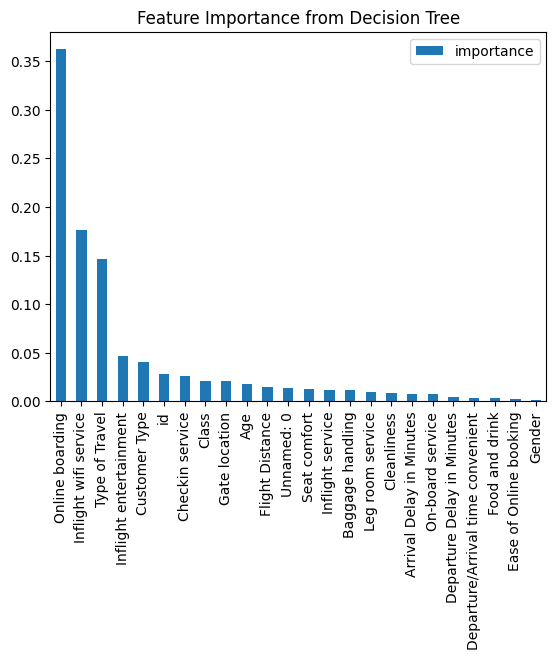

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importances and match them with column names
feature_importances = pd.DataFrame(dt_classifier.feature_importances_,
                                   index = X_train.columns,
                                   columns=['importance']).sort_values('importance', ascending=False)

# Display the feature importances
print("Feature Importances:")
print(feature_importances)

# Plot feature importances for better visualization
plt.figure(figsize=(10, 6))
feature_importances.plot(kind='bar')
plt.title('Feature Importance from Decision Tree')
plt.show()


In [ ]:

import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import graphviz

# Load your dataset
# data = pd.read_csv('path_to_your_data.csv')
# Assuming the target variable is named 'satisfaction' and it's in your dataset
# X = data.drop('satisfaction', axis=1)
# y = data['satisfaction']

# For demonstration, let's assume X_train, X_test, y_train, y_test are already defined
# Example: X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Decision Tree Classifier
clf = DecisionTreeClassifier(max_depth=3)  # Limiting depth to make the tree easier to visualize

# Fit the model
clf.fit(X_train, y_train)

# Predict the Test set results
y_pred = clf.predict(X_test)

# Print out classification report and confusion matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# Visualize the Decision Tree
dot_data = export_graphviz(clf, out_file=None,
                           feature_names=X_train.columns,
                           class_names=['Dissatisfied', 'Satisfied'],
                           filled=True, rounded=True,
                           special_characters=True)
graph = graphviz.Source(dot_data)
graph.render("decision_tree")  # Saves the output as a PDF file named 'decision_tree.pdf'


              precision    recall  f1-score   support

           0       0.92      0.86      0.89     14573
           1       0.84      0.91      0.87     11403

    accuracy                           0.88     25976
   macro avg       0.88      0.89      0.88     25976
weighted avg       0.89      0.88      0.88     25976

[[12601  1972]
 [ 1045 10358]]


'decision_tree.pdf'

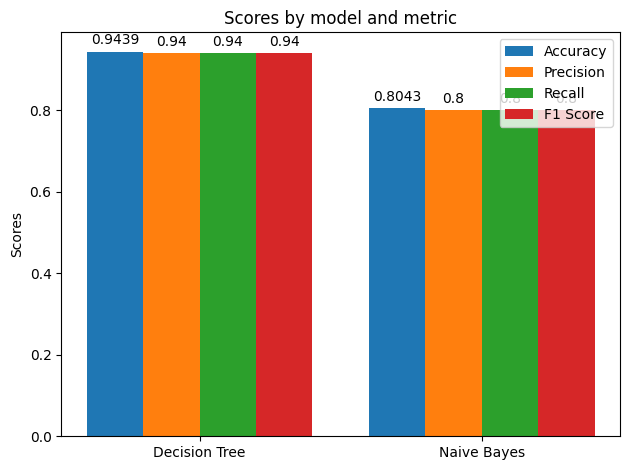

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
models = ['Decision Tree', 'Naive Bayes']
accuracies = [0.9439, 0.8043]  # Replace these values with your actual accuracies
precisions = [0.94, 0.80]      # Replace with actual precision
recalls = [0.94, 0.80]         # Replace with actual recall
f1_scores = [0.94, 0.80]       # Replace with actual F1 scores

x = np.arange(len(models))  # the label locations
width = 0.20  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width*1.5, accuracies, width, label='Accuracy')
rects2 = ax.bar(x - width/2, precisions, width, label='Precision')
rects3 = ax.bar(x + width/2, recalls, width, label='Recall')
rects4 = ax.bar(x + width*1.5, f1_scores, width, label='F1 Score')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Scores')
ax.set_title('Scores by model and metric')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)
ax.bar_label(rects3, padding=3)
ax.bar_label(rects4, padding=3)

fig.tight_layout()

plt.show()


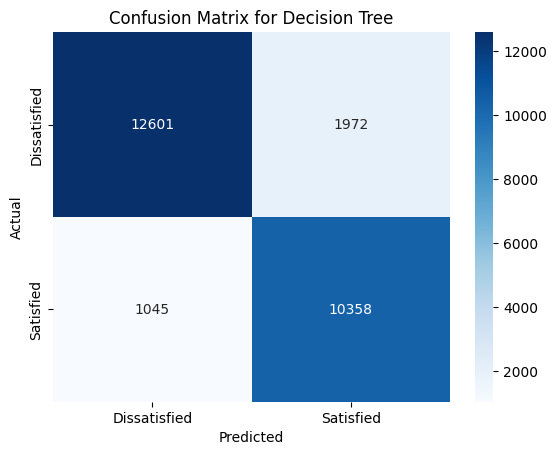

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Assuming y_test and y_pred are available from your model predictions
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=['Dissatisfied', 'Satisfied'], yticklabels=['Dissatisfied', 'Satisfied'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for Decision Tree')
plt.show()


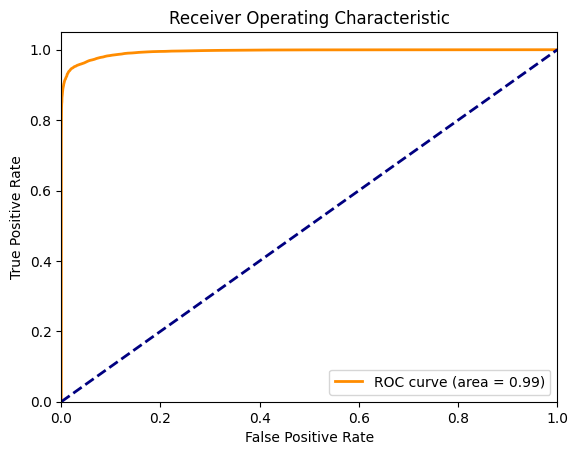

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
from sklearn.ensemble import RandomForestClassifier  # Example classifier

# Example setup: replace with your actual data and model
# Let's assume X_train, X_test, y_train, y_test are already defined and preprocessed

# Train a classifier for demonstration (you can use your existing model)
clf = RandomForestClassifier()  # Change this to your model
clf.fit(X_train, y_train)
y_scores = clf.predict_proba(X_test)[:, 1]  # Get probability scores for the positive class

# Convert y_test to a binary format if it's not already (only necessary if you have multiclass)
lb = LabelBinarizer()
y_test_binarized = lb.fit_transform(y_test)  # Fit label binarizer and transform the test labels

# Calculate the ROC curve points
fpr, tpr, thresholds = roc_curve(y_test_binarized.ravel(), y_scores)

# Calculate the AUC (Area under the ROC Curve)
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


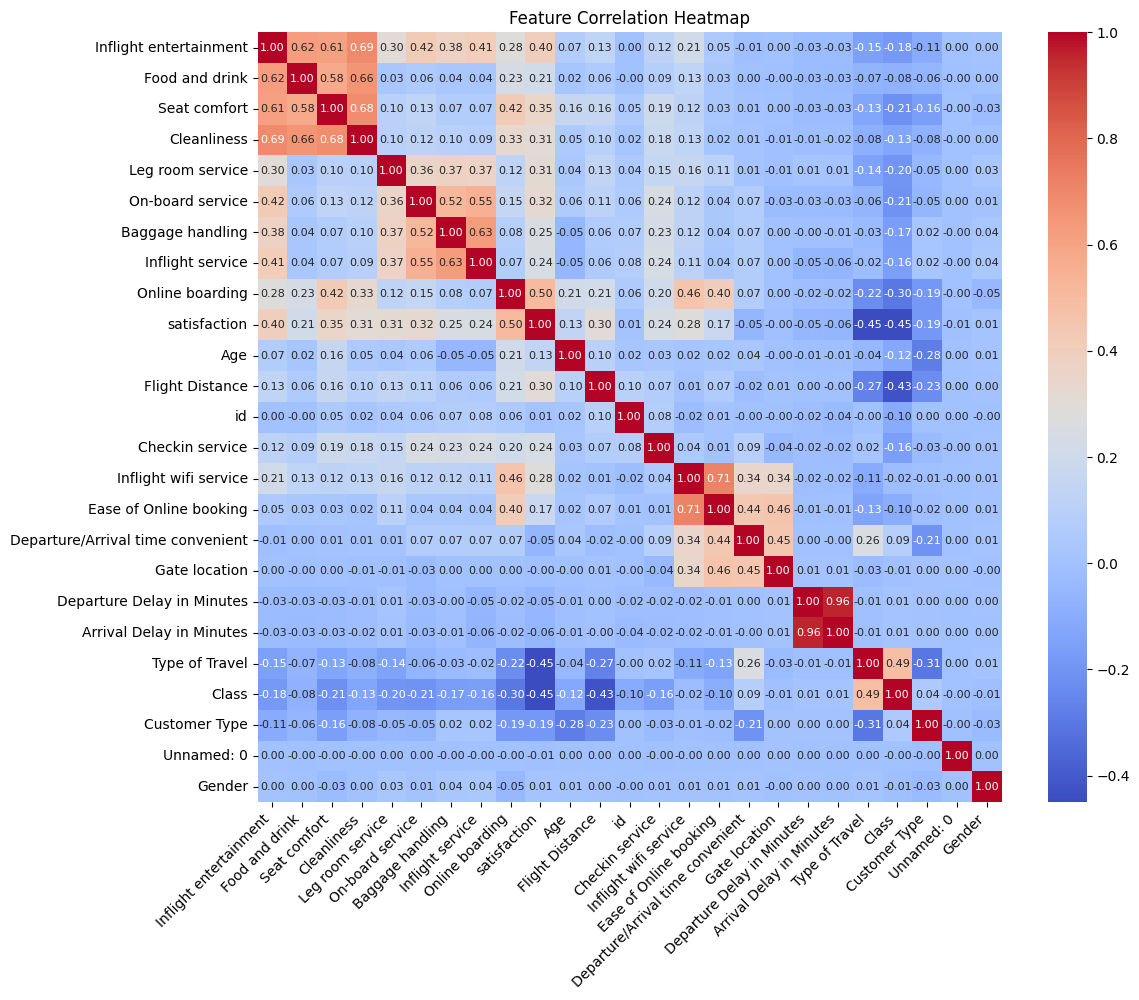

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

# Load your data
# data = pd.read_csv('path_to_your_dataset.csv')

# Calculate the correlation matrix
# corr = data.corr()

# Cluster the features based on the correlation matrix to reorder for better visibility
dendro = sch.dendrogram(sch.linkage(corr, method='ward'), no_plot=True)
clustered_idx = dendro['leaves']

# Rearranged correlation matrix according to clustering
clustered_corr = corr.iloc[clustered_idx, clustered_idx]

# Create a larger plot to accommodate many features
plt.figure(figsize=(12, 10))  # You can adjust the size depending on the number of features

# Generate a heatmap
sns.heatmap(clustered_corr, annot=True, fmt=".2f", cmap='coolwarm', annot_kws={"size": 8},
            cbar=True, xticklabels=clustered_corr.columns, yticklabels=clustered_corr.columns)

# Rotate the x-axis labels for better readability, adjust the rotation as needed
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Feature Correlation Heatmap')

# Show the plot
plt.show()
